# Vaccination Data Analysis and Visualization — EDA

Public Health / Epidemiology capstone. This notebook covers dataset loading, cleaning, and 20 charts (Univariate, Bivariate, Multivariate) with insights.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Know Your Data

### Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### Dataset Loading

Export each table from MySQL Workbench as CSV first (right-click a table's result grid → Export, or `SELECT * FROM table;` then Export Recordset), then upload them here.

Expected files: `countries.csv`, `coverage_data.csv`, `disease_cases.csv`, `vaccine_introduction.csv`, `vaccine_schedule.csv`


In [10]:
from google.colab import files
uploaded = files.upload()  # select all 5 CSVs at once


Saving Diphtheria Tetanus Toxoid and Pertussis (DTP) booster vaccination coverage 2026-16-09 12-02 UTC.xlsx to Diphtheria Tetanus Toxoid and Pertussis (DTP) booster vaccination coverage 2026-16-09 12-02 UTC (2).xlsx
Saving Vaccination schedule for Japanese Encephalitis 2026-16-09 11-47 UTC.xlsx to Vaccination schedule for Japanese Encephalitis 2026-16-09 11-47 UTC (2).xlsx
Saving Vaccination schedule for Dengue 2026-16-09 14-51 UTC.xlsx to Vaccination schedule for Dengue 2026-16-09 14-51 UTC (2).xlsx
Saving Introduction of Hepatitis A vaccine 2026-16-09 16-35 UTC.xlsx to Introduction of Hepatitis A vaccine 2026-16-09 16-35 UTC (2).xlsx
Saving Vaccination schedule for Cholera 2026-16-09 13-18 UTC.xlsx to Vaccination schedule for Cholera 2026-16-09 13-18 UTC (2).xlsx
Saving Congenital Rubella Syndrome (CRS) reported cases and incidence 2026-16-09 12-45 UTC.xlsx to Congenital Rubella Syndrome (CRS) reported cases and incidence 2026-16-09 12-45 UTC (1).xlsx


In [12]:
import pandas as pd
import io # Import the io module to handle in-memory bytes

# Dictionary of uploaded files (filenames as keys, file content as values)
# The `uploaded` variable is available from the previous `files.upload()` cell.
# We need to map the generic names used in the original code to the actual uploaded filenames.

# --- Identify and load each specific dataframe ---

# Assuming 'coverage_data' corresponds to the file containing "coverage"
coverage_file = [f for f in uploaded.keys() if "coverage" in f.lower()]
if coverage_file:
    coverage_data = pd.read_excel(io.BytesIO(uploaded[coverage_file[0]])) # Use io.BytesIO for in-memory file content
else:
    coverage_data = pd.DataFrame() # Placeholder if not found
    print("Warning: coverage_data file not found among uploaded files.")

# Assuming 'disease_cases' corresponds to the file containing "cases" or "incidence"
disease_cases_file = [f for f in uploaded.keys() if "cases" in f.lower() or "incidence" in f.lower()]
if disease_cases_file:
    disease_cases = pd.read_excel(io.BytesIO(uploaded[disease_cases_file[0]])) # Use io.BytesIO for in-memory file content
else:
    disease_cases = pd.DataFrame() # Placeholder if not found
    print("Warning: disease_cases file not found among uploaded files.")

# Assuming 'vaccine_introduction' corresponds to the file containing "introduction" and "vaccine"
intro_file = [f for f in uploaded.keys() if "introduction" in f.lower() and "vaccine" in f.lower()]
if intro_file:
    vaccine_introduction = pd.read_excel(io.BytesIO(uploaded[intro_file[0]])) # Use io.BytesIO for in-memory file content
else:
    vaccine_introduction = pd.DataFrame() # Placeholder if not found
    print("Warning: vaccine_introduction file not found among uploaded files.")

# For 'vaccine_schedule', there might be multiple files. Combine them.
schedule_files = [f for f in uploaded.keys() if "vaccination schedule" in f.lower()]
if schedule_files:
    vaccine_schedule_list = [pd.read_excel(io.BytesIO(uploaded[f])) for f in schedule_files] # Use io.BytesIO for each file
    vaccine_schedule = pd.concat(vaccine_schedule_list, ignore_index=True)
else:
    vaccine_schedule = pd.DataFrame() # Placeholder if not found
    print("Warning: vaccine_schedule files not found among uploaded files.")

# The 'countries' file was not found among the uploaded Excel files.
# It was expected as 'countries.csv' but no corresponding .xlsx file was identified.
# For now, it's an empty DataFrame. You may need to upload 'countries.csv' or 'countries.xlsx' separately.
countries = pd.DataFrame()
print("Warning: 'countries' data file (e.g., countries.csv or countries.xlsx) not found among uploaded files.")

tables = {
    "countries": countries,
    "coverage_data": coverage_data,
    "disease_cases": disease_cases,
    "vaccine_introduction": vaccine_introduction,
    "vaccine_schedule": vaccine_schedule,
}

### Dataset First View

In [13]:
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df.head())


--- countries ---


""


--- coverage_data ---


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,AFG,Afghanistan,2025.0,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos...",ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,AFG,Afghanistan,2025.0,TTCV5,"Tetanus-containing vaccine, 5th dose (2nd boos...",ADMIN,Administrative coverage,NaN,NaN,NaN
2,COUNTRIES,ALB,Albania,2025.0,TTCV5,"Tetanus-containing vaccine, 5th dose (2nd boos...",ADMIN,Administrative coverage,23317.0,20987.0,90.01
3,COUNTRIES,ALB,Albania,2025.0,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos...",ADMIN,Administrative coverage,26857.0,22509.0,83.81
4,COUNTRIES,DZA,Algeria,2025.0,TTCV6,"Tetanus-containing vaccine, 6th dose (3rd boos...",ADMIN,Administrative coverage,609464.0,573433.0,94.09


--- disease_cases ---


,Country / Region,Disease,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,African Region,Congenital rubella syndrome,120.0,77.0,124.0,5.0,100.0,28.0,9.0,18.0,...,47.0,0.0,1.0,8.0,3.0,4.0,9.0,0.0,0.0,0.0
1,Eastern Mediterranean Region,Congenital rubella syndrome,310.0,305.0,836.0,933.0,200.0,958.0,26.0,39.0,...,67.0,1.0,0.0,23.0,1.0,3.0,1.0,0.0,2.0,0.0
2,European Region,Congenital rubella syndrome,7.0,1.0,5.0,2.0,2.0,2.0,9.0,14.0,...,16.0,9.0,31.0,16.0,16.0,32.0,13.0,7.0,21.0,47.0
3,Region of the Americas,Congenital rubella syndrome,0.0,1.0,2.0,0.0,0.0,2.0,0.0,0.0,...,17.0,230.0,19.0,15.0,20.0,27.0,30.0,23.0,41.0,80.0
4,South-East Asia Region,Congenital rubella syndrome,77.0,14.0,301.0,381.0,172.0,138.0,160.0,154.0,...,3.0,0.0,0.0,2.0,0.0,20.0,61.0,8.0,13.0,26.0


--- vaccine_introduction ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,ANTIGEN,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2002.0,HEPA,Hepatitis A vaccine,No
1,ALB,Albania,EURO,2002.0,HEPA,Hepatitis A vaccine,No
2,DZA,Algeria,AFRO,2002.0,HEPA,Hepatitis A vaccine,No
3,AND,Andorra,EURO,2002.0,HEPA,Hepatitis A vaccine,No
4,AGO,Angola,AFRO,2002.0,HEPA,Hepatitis A vaccine,No


--- vaccine_schedule ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT,VACCINEDESCRIPTION,VACCINEDESCRIPTIONSHORT,DISEASECODE,DISEASEDESCRIPTION,SCHEDULERCODE
0,BMU,Bermuda,AMRO,2025.0,JE_INACTD,JE-Inact (Japanese Encephalitis inactivated) v...,1.0,TRAVELLERS,Travellers,NATIONAL,1st contact,Travellers to high-risk areas,JE-Inact (Japanese Encephalitis inactivated) v...,JE-inactd,JAPENC,Japanese encephalitis,JE-IV
1,BMU,Bermuda,AMRO,2025.0,JE_INACTD,JE-Inact (Japanese Encephalitis inactivated) v...,2.0,TRAVELLERS,Travellers,NATIONAL,+D28,Travellers to high-risk areas,JE-Inact (Japanese Encephalitis inactivated) v...,JE-inactd,JAPENC,Japanese encephalitis,JE-IV
2,CHE,Switzerland,EURO,2025.0,JE_INACTD,JE-Inact (Japanese Encephalitis inactivated) v...,1.0,TRAVELLERS,Travellers,NaN,NaN,Travellers only,JE-Inact (Japanese Encephalitis inactivated) v...,JE-inactd,JAPENC,Japanese encephalitis,JE-IV
3,CHN,China,WPRO,2025.0,JE_INACTD,JE-Inact (Japanese Encephalitis inactivated) v...,1.0,NaN,General/routine,SUBNATIONAL,M8,2nd dose is administered +7-10 days after the ...,JE-Inact (Japanese Encephalitis inactivated) v...,JE-inactd,JAPENC,Japanese encephalitis,JE-IV
4,CHN,China,WPRO,2025.0,JE_LIVEATD,JE-Livatd (Japanese Encephalitis live-attenuat...,1.0,NaN,General/routine,NATIONAL,M8,NaN,JE-Livatd (Japanese Encephalitis live-attenuat...,JE-livatd,JAPENC,Japanese encephalitis,JE-LV


### Dataset Rows & Columns count

In [14]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")


countries: 0 rows, 0 columns
coverage_data: 23037 rows, 11 columns
disease_cases: 7 rows, 28 columns
vaccine_introduction: 4644 rows, 7 columns
vaccine_schedule: 69 rows, 17 columns


### Dataset Information

In [15]:
for name, df in tables.items():
    print(f"--- {name} ---")
    df.info()
    print()


--- countries ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame

--- coverage_data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23037 entries, 0 to 23036
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   GROUP                          23037 non-null  object 
 1   CODE                           23036 non-null  object 
 2   NAME                           23036 non-null  object 
 3   YEAR                           23036 non-null  float64
 4   ANTIGEN                        23036 non-null  object 
 5   ANTIGEN_DESCRIPTION            23036 non-null  object 
 6   COVERAGE_CATEGORY              23036 non-null  object 
 7   COVERAGE_CATEGORY_DESCRIPTION  23036 non-null  object 
 8   TARGET_NUMBER                  5699 non-null   float64
 9   DOSES                          5719 non-null   float64
 10  COVERAGE                       11458 non-null  fl

#### Duplicate Values

In [16]:
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")


countries: 0 duplicate rows
coverage_data: 0 duplicate rows
disease_cases: 0 duplicate rows
vaccine_introduction: 0 duplicate rows
vaccine_schedule: 0 duplicate rows


#### Missing Values/Null Values

In [17]:
for name, df in tables.items():
    print(f"--- {name} ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print()


--- countries ---
Series([], dtype: float64)

--- coverage_data ---
CODE                                 1
NAME                                 1
YEAR                                 1
ANTIGEN                              1
ANTIGEN_DESCRIPTION                  1
COVERAGE_CATEGORY                    1
COVERAGE_CATEGORY_DESCRIPTION        1
TARGET_NUMBER                    17338
DOSES                            17318
COVERAGE                         11579
dtype: int64

--- disease_cases ---
Disease    1
2025       1
2024       1
2023       1
2022       1
2021       1
2020       1
2019       1
2018       1
2017       1
2016       1
2015       1
2014       1
2013       1
2012       1
2011       1
2010       1
2009       1
2008       1
2007       1
2006       1
2005       1
2004       1
2003       1
2002       1
2001       1
2000       1
dtype: int64

--- vaccine_introduction ---
COUNTRYNAME    1
WHO_REGION     1
YEAR           1
ANTIGEN        1
DESCRIPTION    1
INTRO          1
dtype: int

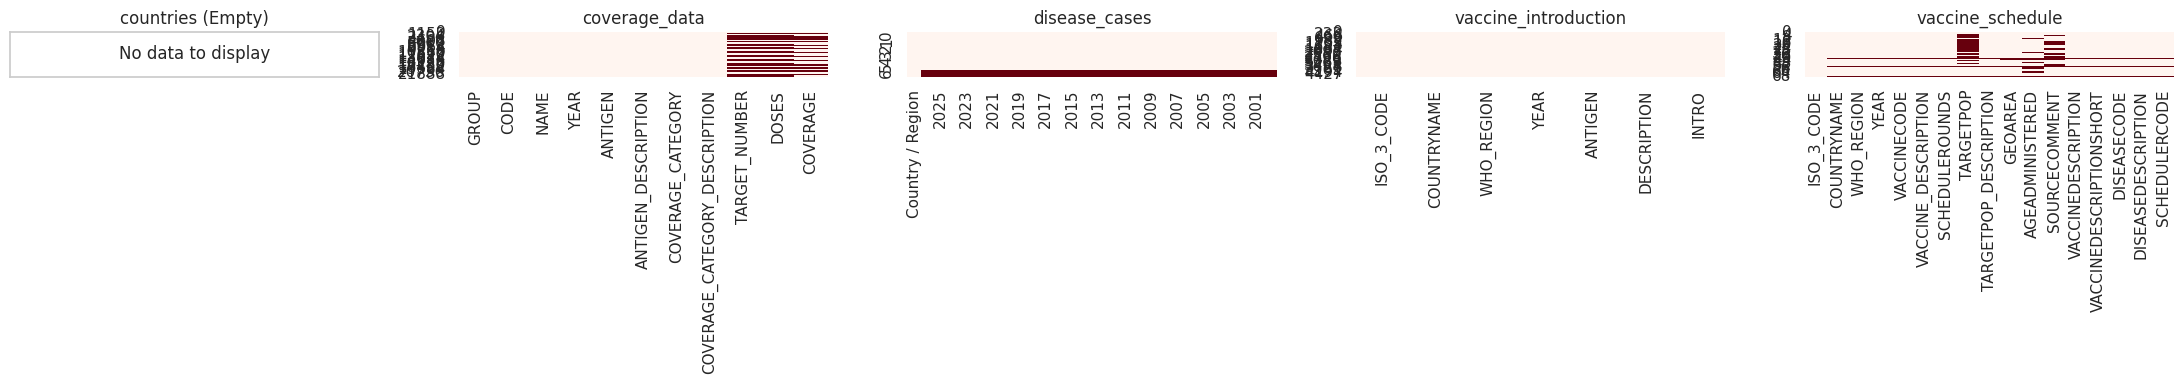

In [19]:
fig, axes = plt.subplots(1, len(tables), figsize=(22, 4))
# Ensure axes is always an array, even if there's only one subplot
if len(tables) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, tables.items()):
    if not df.empty:
        sns.heatmap(df.isnull(), cbar=False, ax=ax, cmap="Reds")
        ax.set_title(name)
    else:
        ax.set_title(f"{name} (Empty)")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.5, 0.5, "No data to display", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

### What did you know about your dataset?

*(Fill this in after running the cells above — note row/column counts, which tables have missing values, and any obvious data quality issues you spot.)*


## 2. Understanding Your Variables

In [20]:
for name, df in tables.items():
    print(f"--- {name} columns ---")
    print(list(df.columns))
    print()


--- countries columns ---
[]

--- coverage_data columns ---
['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']

--- disease_cases columns ---
['Country / Region', 'Disease', 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000]

--- vaccine_introduction columns ---
['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'ANTIGEN', 'DESCRIPTION', 'INTRO']

--- vaccine_schedule columns ---
['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT', 'VACCINEDESCRIPTION', 'VACCINEDESCRIPTIONSHORT', 'DISEASECODE', 'DISEASEDESCRIPTION', 'SCHEDULERCODE']



In [21]:
coverage_data.describe(include="all")


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
count,23037,23036,23036,23036.000000,23036,23036,23036,23036,5.699000e+03,5.719000e+03,11458.000000
unique,2,216,216,NaN,7,7,2,2,NaN,NaN,NaN
top,COUNTRIES,AFG,Afghanistan,NaN,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,NaN,NaN,NaN
freq,23036,112,112,NaN,3292,3292,11523,11523,NaN,NaN,NaN
mean,NaN,NaN,NaN,2021.512155,NaN,NaN,NaN,NaN,4.916543e+05,3.864036e+05,84.603791
std,NaN,NaN,NaN,2.298871,NaN,NaN,NaN,NaN,2.189866e+06,1.828879e+06,177.705074
min,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000
25%,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,6.688000e+03,4.640000e+03,74.000000
50%,NaN,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,5.968000e+04,4.892700e+04,87.770000
75%,NaN,NaN,NaN,2024.000000,NaN,NaN,NaN,NaN,3.180010e+05,2.282960e+05,95.000000


### Check Unique Values for each variable

In [22]:
for name, df in tables.items():
    print(f"--- {name} ---")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
    print()


--- countries ---

--- coverage_data ---
GROUP: 2 unique values
CODE: 216 unique values
NAME: 216 unique values
YEAR: 8 unique values
ANTIGEN: 7 unique values
ANTIGEN_DESCRIPTION: 7 unique values
COVERAGE_CATEGORY: 2 unique values
COVERAGE_CATEGORY_DESCRIPTION: 2 unique values
TARGET_NUMBER: 2317 unique values
DOSES: 2579 unique values
COVERAGE: 1948 unique values

--- disease_cases ---
Country / Region: 7 unique values
Disease: 1 unique values
2025: 6 unique values
2024: 5 unique values
2023: 6 unique values
2022: 6 unique values
2021: 6 unique values
2020: 5 unique values
2019: 5 unique values
2018: 6 unique values
2017: 6 unique values
2016: 6 unique values
2015: 6 unique values
2014: 6 unique values
2013: 6 unique values
2012: 6 unique values
2011: 6 unique values
2010: 5 unique values
2009: 6 unique values
2008: 5 unique values
2007: 5 unique values
2006: 6 unique values
2005: 5 unique values
2004: 5 unique values
2003: 6 unique values
2002: 5 unique values
2001: 6 unique values
2

## 3. Data Wrangling

In [25]:
# Standardize column names
# Iterate through keys to ensure the modified DataFrame is assigned back to the dictionary
for name in tables.keys():
    df = tables[name]
    df.columns = [str(c).strip().lower() for c in df.columns]
    tables[name] = df # Update the DataFrame in the dictionary

# Drop exact duplicate rows
for name in tables.keys():
    df = tables[name]
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    if before != after:
        print(f"{name}: removed {before - after} duplicate rows")
    tables[name] = df # Update the DataFrame in the dictionary if duplicates were removed

# Now fetch the dataframes into local variables for easier manipulation
coverage_data = tables['coverage_data']
disease_cases = tables['disease_cases']
vaccine_introduction = tables['vaccine_introduction']
vaccine_schedule = tables['vaccine_schedule']


# Coverage: drop rows with no coverage value, coverage should be 0-100
if not coverage_data.empty:
    coverage_data = coverage_data.dropna(subset=["coverage"])
    coverage_data = coverage_data[(coverage_data["coverage"] >= 0) & (coverage_data["coverage"] <= 100)]
tables['coverage_data'] = coverage_data # Update back to dictionary


# Reshape disease_cases if it's not empty
if not disease_cases.empty:
    # Identify year columns (which are now strings due to earlier standardization)
    id_vars = ['country / region', 'disease']
    # Filter out columns that are not id_vars; the rest are assumed to be year columns
    year_cols = [col for col in disease_cases.columns if col not in id_vars]

    # Melt the DataFrame
    disease_cases = disease_cases.melt(
        id_vars=id_vars,
        value_vars=year_cols,
        var_name='year',
        value_name='cases'
    )
    # Convert 'cases' to numeric, coerce errors to NaN, then drop NaNs and filter non-negative
    disease_cases['cases'] = pd.to_numeric(disease_cases['cases'], errors='coerce')
    disease_cases = disease_cases.dropna(subset=['cases'])
    disease_cases = disease_cases[disease_cases["cases"] >= 0]
tables['disease_cases'] = disease_cases # Update back to dictionary


# Ensure year columns are integers
# Iterate through specific dataframe names to update them in the tables dictionary
for df_name in ["coverage_data", "disease_cases", "vaccine_introduction", "vaccine_schedule"]:
    df = tables[df_name]
    # Check if 'year' column exists and if the DataFrame is not empty
    if "year" in df.columns and not df.empty:
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df.dropna(subset=["year"], inplace=True)
        df["year"] = df["year"].astype(int)
    tables[df_name] = df # Always update back to the dictionary

print("Cleaning done.")
print("coverage_data:", tables['coverage_data'].shape)
print("disease_cases:", tables['disease_cases'].shape)

Cleaning done.
coverage_data: (11178, 11)
disease_cases: (156, 4)


### What all manipulations have you done and insights you found?

*(Fill in after running — e.g. "Removed N duplicate rows from X, dropped rows with missing coverage values, filtered out invalid negative case counts, standardized year to integer type.")*


## 4. Data Visualization, Storytelling & Experimenting with Charts

#### Chart - 1 — Distribution of Coverage % (Univariate)

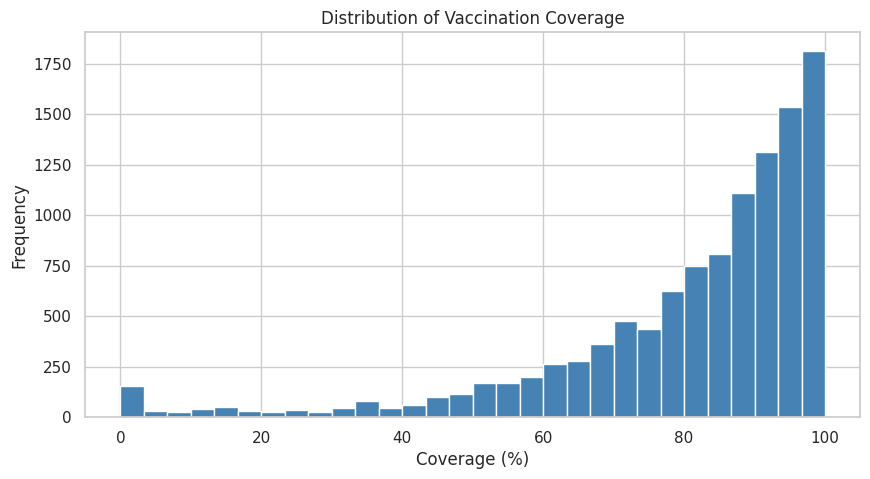

In [26]:
plt.hist(coverage_data["coverage"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Coverage (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Vaccination Coverage")
plt.show()


##### 1. Why did you pick the specific chart?

A histogram shows the overall shape of a single numeric variable — here, how coverage percentages are distributed across all records.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: is coverage skewed toward high values, is there a cluster near 0%, etc.)*


##### 3. Will the gained insights help creating a positive business impact?

Understanding the overall coverage distribution helps identify whether low coverage is a widespread problem or isolated to a few records.


#### Chart - 2 — Count of Records by WHO Region (Univariate)

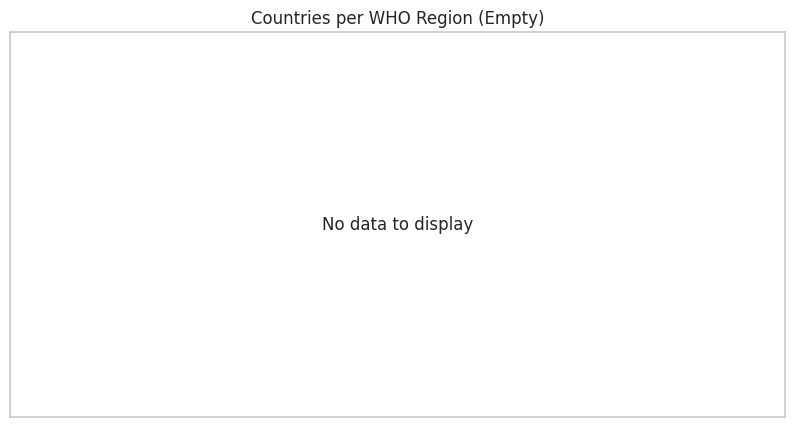

In [28]:
if not countries.empty:
    countries["who_region"].value_counts().plot(kind="bar", color="coral")
    plt.xlabel("WHO Region")
    plt.ylabel("Number of Countries")
    plt.title("Countries per WHO Region")
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5)) # Create a figure and an axes object
    ax.set_title("Countries per WHO Region (Empty)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, "No data to display", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the standard way to show frequency counts of a categorical variable across a small number of categories.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which region has the most/fewest countries represented.)*


##### 3. Will the gained insights help creating a positive business impact?

Shows if any WHO region is under-represented in the dataset, which matters for how confidently we can generalize findings per region.


#### Chart - 3 — Distribution of Doses Administered (Univariate)

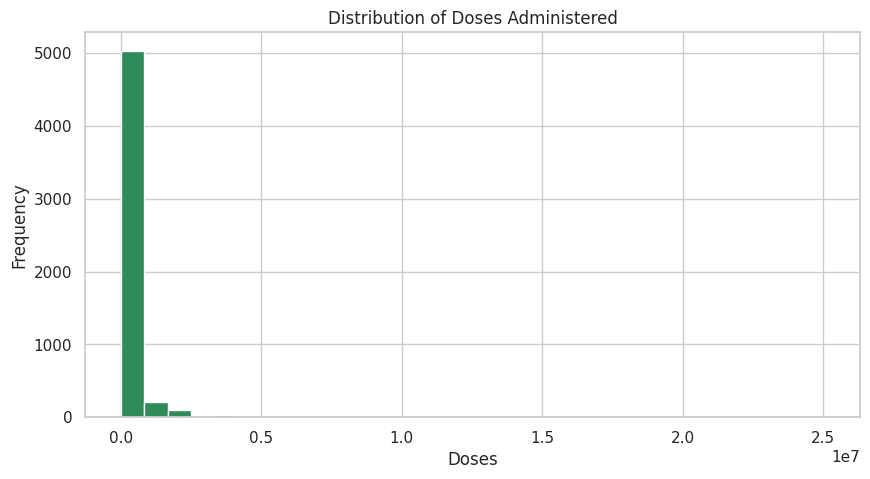

In [29]:
plt.hist(coverage_data["doses"].dropna(), bins=30, color="seagreen", edgecolor="white")
plt.xlabel("Doses")
plt.ylabel("Frequency")
plt.title("Distribution of Doses Administered")
plt.show()


##### 1. Why did you pick the specific chart?

Histogram to understand the spread and skew of the doses-administered variable, a key operational metric.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: is it heavily right-skewed, i.e. most records have low doses with a few very large outliers?)*


##### 3. Will the gained insights help creating a positive business impact?

Identifies whether a small number of large-scale campaigns dominate the dose counts, useful for resource planning.


#### Chart - 4 — Distribution of Reported Disease Cases (Univariate)

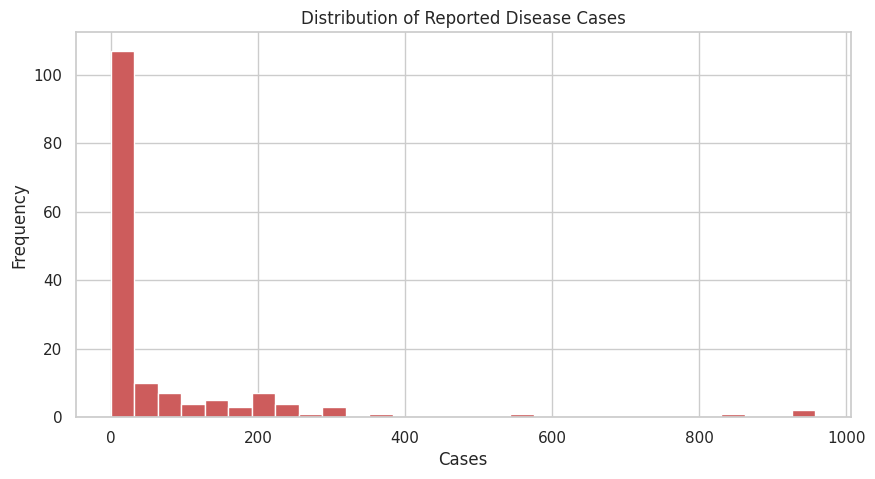

In [30]:
plt.hist(disease_cases["cases"], bins=30, color="indianred", edgecolor="white")
plt.xlabel("Cases")
plt.ylabel("Frequency")
plt.title("Distribution of Reported Disease Cases")
plt.show()


##### 1. Why did you pick the specific chart?

Histogram to see how reported case counts are distributed — disease data is often heavily right-skewed with a long tail of outbreak years.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: most values clustered near zero with a long tail of high-case years/regions?)*


##### 3. Will the gained insights help creating a positive business impact?

Highlights that a small number of region-years account for most disease burden — useful for targeting interventions.


#### Chart - 5 — Coverage Category Breakdown (Univariate)

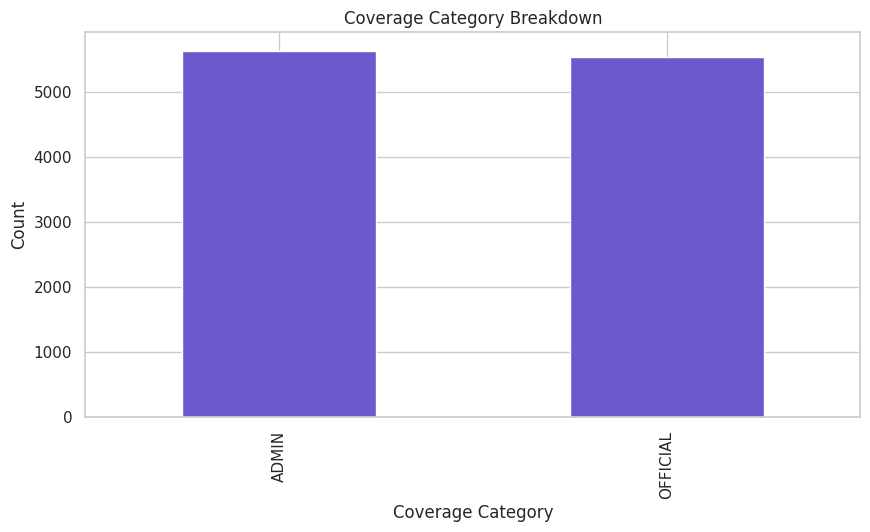

In [31]:
coverage_data["coverage_category"].value_counts().plot(kind="bar", color="slateblue")
plt.xlabel("Coverage Category")
plt.ylabel("Count")
plt.title("Coverage Category Breakdown")
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart to see the split between reporting types (e.g. administrative vs official estimates), which affects data reliability.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which category dominates the dataset.)*


##### 3. Will the gained insights help creating a positive business impact?

If one reporting type dominates, it affects how much we should trust cross-country comparisons.


#### Chart - 6 — Average Coverage by Year (Bivariate)

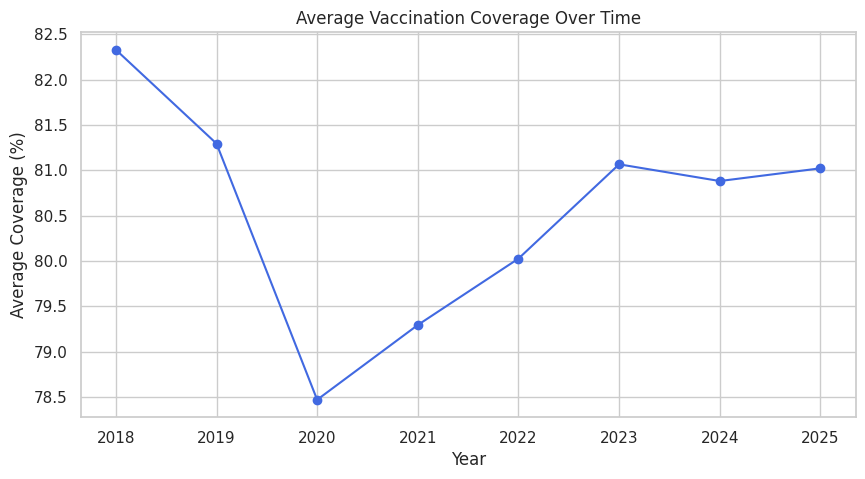

In [32]:
yearly_cov = coverage_data.groupby("year")["coverage"].mean()
yearly_cov.plot(kind="line", marker="o", color="royalblue")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.title("Average Vaccination Coverage Over Time")
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is ideal for showing a trend of a numeric value across time.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: look for a dip, e.g. around 2020, and recovery pattern afterward.)*


##### 3. Will the gained insights help creating a positive business impact?

A visible dip (e.g. pandemic-era disruption) followed by recovery directly informs how resilient vaccination programs are to shocks — critical for policy planning.


#### Chart - 7 — Average Coverage by WHO Region (Bivariate)

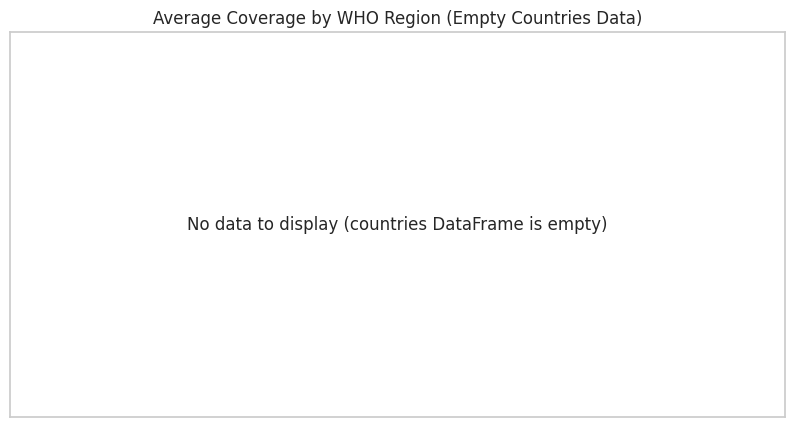

In [34]:
if not countries.empty:
    # Assuming 'code' in coverage_data is the country identifier (e.g., ISO-3 code)
    # and countries DataFrame (if populated) would have 'iso_3_code' and 'who_region'.
    merged = coverage_data.merge(countries, left_on="code", right_on="iso_3_code", how="left")

    # Check if 'who_region' exists after merge and has data, as it might be missing if countries was empty
    # or if the merge failed to find matches, leading to all NaNs.
    if "who_region" in merged.columns and not merged["who_region"].isnull().all():
        region_cov = merged.groupby("who_region")["coverage"].mean().sort_values()
        region_cov.plot(kind="barh", color="teal")
        plt.xlabel("Average Coverage (%)")
        plt.title("Average Coverage by WHO Region")
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_title("Average Coverage by WHO Region (No Region Data)")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.5, 0.5, "No 'who_region' data after merge", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Average Coverage by WHO Region (Empty Countries Data)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, "No data to display (countries DataFrame is empty)", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart to compare a numeric average across a categorical grouping (region), sorted for easy reading.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which region has lowest/highest average coverage.)*


##### 3. Will the gained insights help creating a positive business impact?

Directly answers the brief's question on regional disparities — pinpoints where targeted intervention is most needed.


#### Chart - 8 — Coverage Spread by Category (Bivariate)

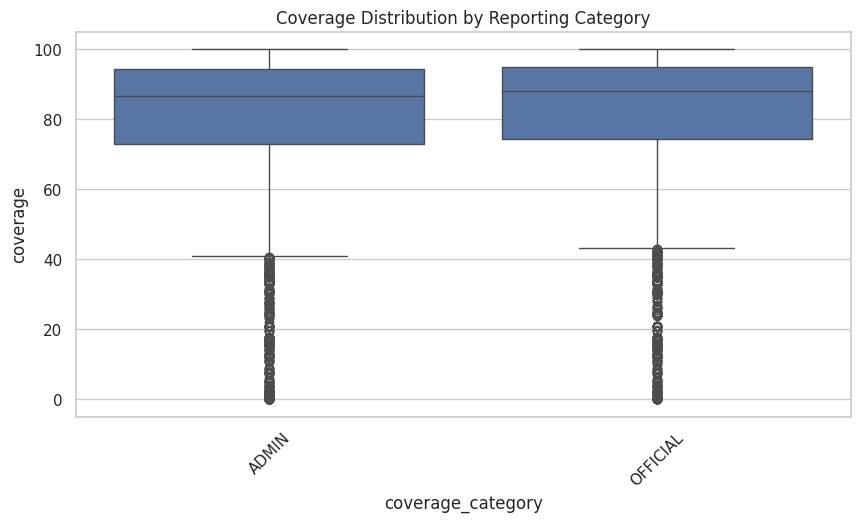

In [35]:
sns.boxplot(data=coverage_data, x="coverage_category", y="coverage")
plt.xticks(rotation=45)
plt.title("Coverage Distribution by Reporting Category")
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot shows both the central tendency and spread/outliers of a numeric variable across categories — more informative than a bar of means alone.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: does one reporting category show much wider variance or more outliers?)*


##### 3. Will the gained insights help creating a positive business impact?

Flags whether certain reporting categories are less reliable/more volatile, informing which figures to trust most.


#### Chart - 9 — Total Disease Cases by Year (Bivariate)

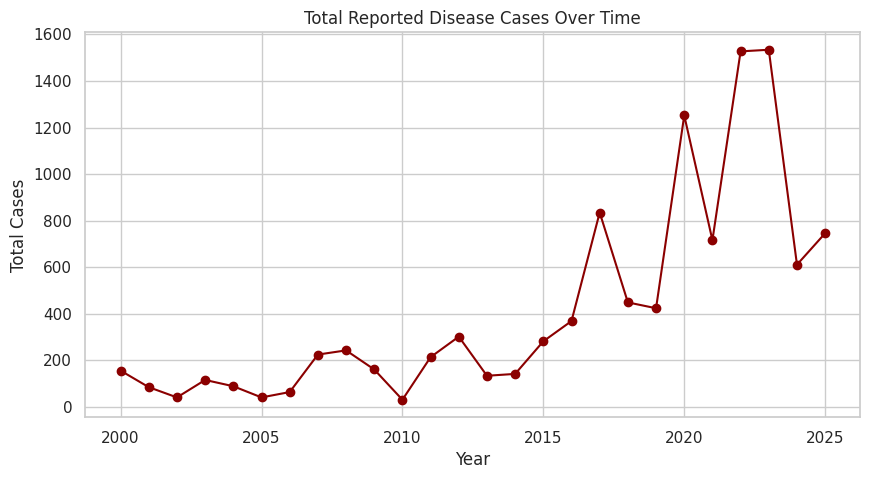

In [36]:
disease_cases.groupby("year")["cases"].sum().plot(kind="line", marker="o", color="darkred")
plt.xlabel("Year")
plt.ylabel("Total Cases")
plt.title("Total Reported Disease Cases Over Time")
plt.show()


##### 1. Why did you pick the specific chart?

Line chart to track total case counts over time, directly comparable to the coverage-over-time chart above.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: does case count fall as coverage rises, or spike in specific years?)*


##### 3. Will the gained insights help creating a positive business impact?

Case-count trend is the clearest evidence of whether vaccination efforts are working over time.


#### Chart - 10 — Total Cases by Region (Bivariate)

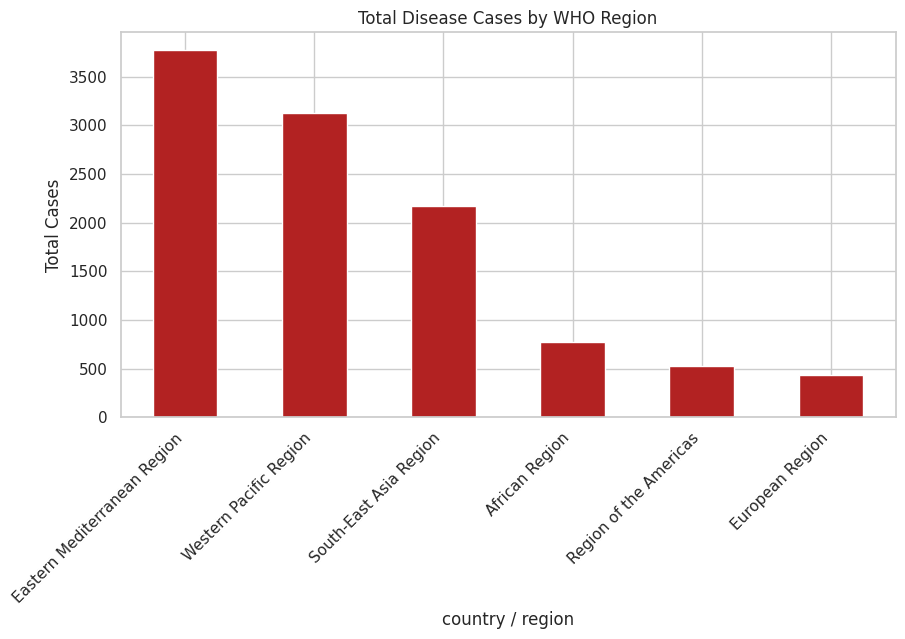

In [38]:
disease_cases.groupby("country / region")["cases"].sum().sort_values(ascending=False).plot(kind="bar", color="firebrick")
plt.ylabel("Total Cases")
plt.title("Total Disease Cases by WHO Region")
plt.xticks(rotation=45, ha="right")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart ranks regions by total disease burden — useful for immediate comparison.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which region carries the highest case burden.)*


##### 3. Will the gained insights help creating a positive business impact?

Identifies where disease burden is concentrated, supporting resource allocation decisions.


#### Chart - 11 — Coverage vs Doses Administered (Bivariate)

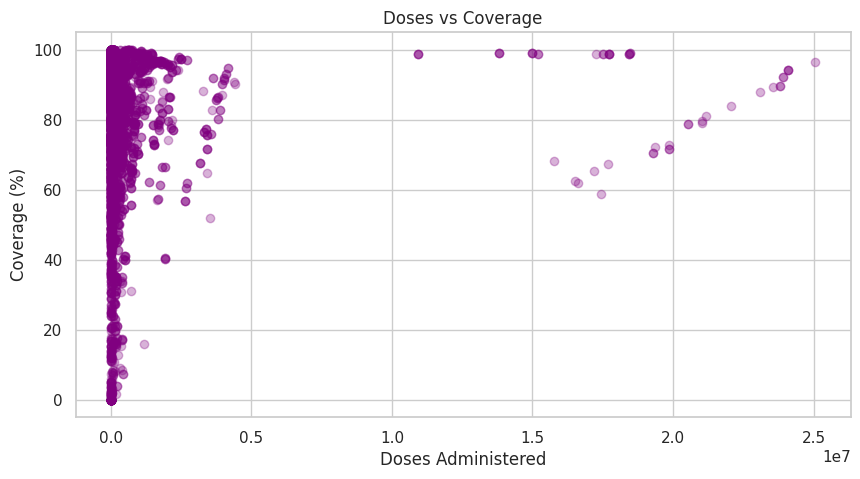

In [39]:
plt.scatter(coverage_data["doses"], coverage_data["coverage"], alpha=0.3, color="purple")
plt.xlabel("Doses Administered")
plt.ylabel("Coverage (%)")
plt.title("Doses vs Coverage")
plt.show()


##### 1. Why did you pick the specific chart?

Scatter plot is the standard way to explore the relationship between two continuous numeric variables.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: is there a clear positive relationship, or does it plateau?)*


##### 3. Will the gained insights help creating a positive business impact?

Confirms whether simply administering more doses reliably converts into higher coverage percentage, or whether other factors (population size) dominate.


#### Chart - 12 — Target Population vs Doses Administered (Bivariate)

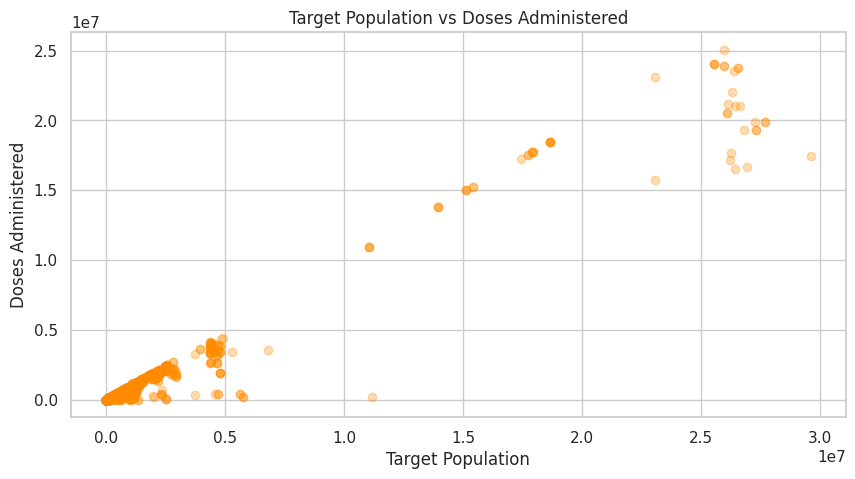

In [40]:
plt.scatter(coverage_data["target_number"], coverage_data["doses"], alpha=0.3, color="darkorange")
plt.xlabel("Target Population")
plt.ylabel("Doses Administered")
plt.title("Target Population vs Doses Administered")
plt.show()


##### 1. Why did you pick the specific chart?

Scatter plot to check whether larger target populations proportionally receive more doses.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: is the relationship roughly linear, i.e. proportional coverage effort regardless of population size?)*


##### 3. Will the gained insights help creating a positive business impact?

Reveals whether larger target populations are under-served relative to smaller ones — an equity check.


#### Chart - 13 — Top 10 Countries by Average Coverage (Bivariate)

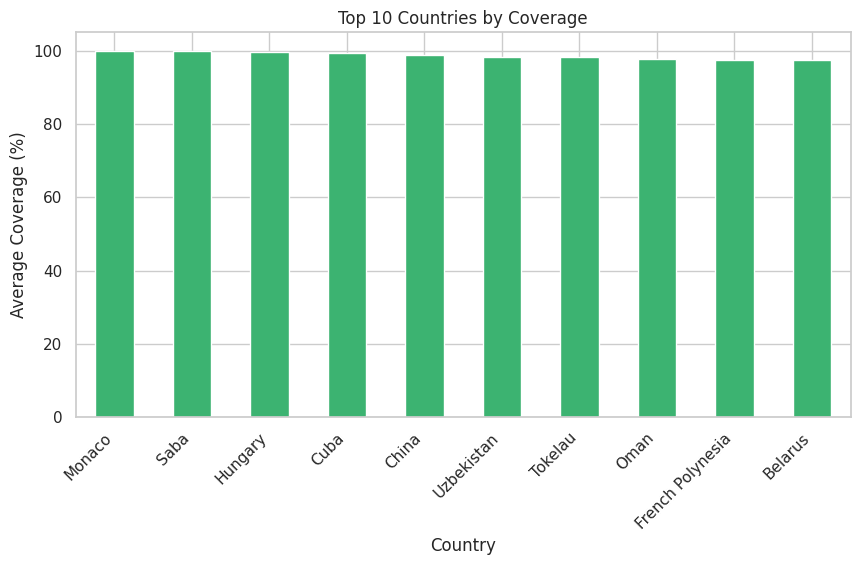

In [42]:
if not coverage_data.empty:
    top10 = coverage_data.groupby("name")["coverage"].mean().sort_values(ascending=False).head(10)
    top10.plot(kind="bar", color="mediumseagreen")
    plt.xlabel("Country") # Changed from 'country_name' to 'Country' for clarity
    plt.ylabel("Average Coverage (%)")
    plt.title("Top 10 Countries by Coverage")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Top 10 Countries by Coverage (No Data)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, "No coverage data to display", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.show()

##### 1. Why did you pick the specific chart?

Ranked bar chart to spotlight the best-performing countries.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe the top countries and their approximate coverage %.)*


##### 3. Will the gained insights help creating a positive business impact?

Identifies which countries' vaccination strategies might be worth studying as models of best practice.


#### Chart - 14 — Bottom 10 Countries by Average Coverage (Bivariate)

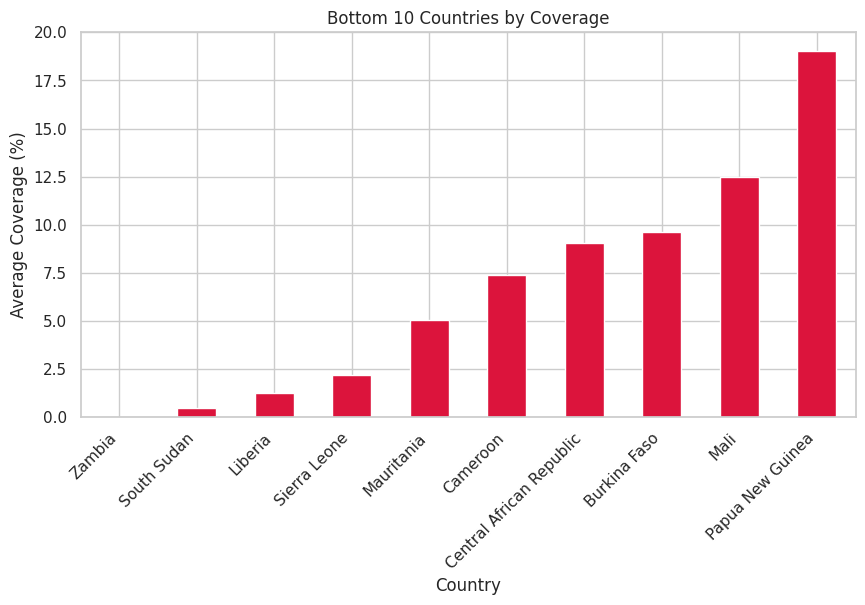

In [44]:
if not coverage_data.empty:
    bottom10 = coverage_data.groupby("name")["coverage"].mean().sort_values().head(10)
    bottom10.plot(kind="bar", color="crimson")
    plt.xlabel("Country") # Changed from 'country_name' to 'Country' for clarity
    plt.ylabel("Average Coverage (%)")
    plt.title("Bottom 10 Countries by Coverage")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Bottom 10 Countries by Coverage (No Data)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, "No coverage data to display", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.show()

##### 1. Why did you pick the specific chart?

Same ranked approach as Chart 13, but isolating the lowest performers, which is more directly actionable.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe the lowest countries and their approximate coverage %.)*


##### 3. Will the gained insights help creating a positive business impact?

Directly answers the brief's scenario: "identify regions with low vaccination coverage to allocate resources effectively."


#### Chart - 15 — Vaccine Introductions by Year (Bivariate)

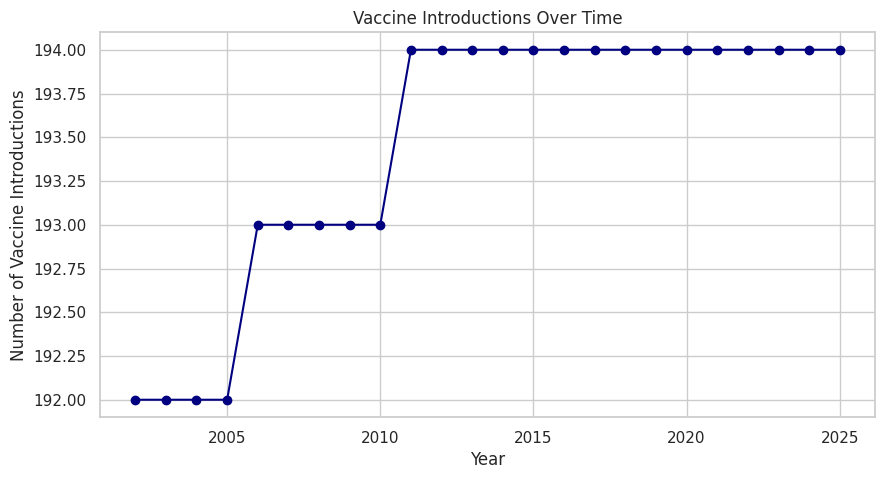

In [45]:
vaccine_introduction.groupby("year").size().plot(kind="line", marker="o", color="navy")
plt.xlabel("Year")
plt.ylabel("Number of Vaccine Introductions")
plt.title("Vaccine Introductions Over Time")
plt.show()


##### 1. Why did you pick the specific chart?

Line chart tracks how the pace of new vaccine rollouts has changed over time.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: any acceleration or slowdown in new vaccine introductions in recent years?)*


##### 3. Will the gained insights help creating a positive business impact?

Shows whether newer vaccines are being adopted faster or slower globally — relevant to policy on new vaccine rollout support.


#### Chart - 16 — Vaccine Introductions by WHO Region (Bivariate)

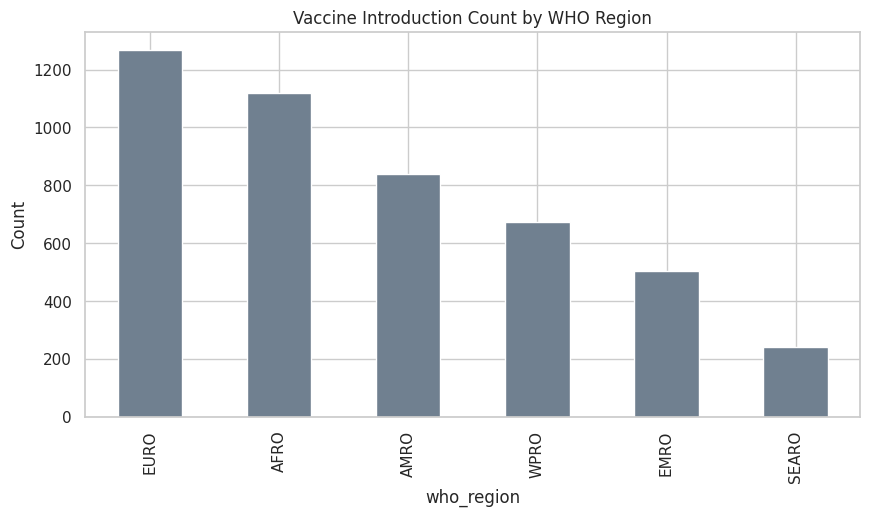

In [46]:
vaccine_introduction["who_region"].value_counts().plot(kind="bar", color="slategray")
plt.ylabel("Count")
plt.title("Vaccine Introduction Count by WHO Region")
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart compares how many vaccine-introduction records exist per region, a proxy for how actively regions have adopted new vaccines.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which regions show fewer introductions — could indicate slower rollout or less complete reporting.)*


##### 3. Will the gained insights help creating a positive business impact?

Flags regions that may be lagging in adopting newer vaccines, useful for global health policy targeting.


#### Chart - 17 — Coverage Trend by Top Antigens Over Time (Multivariate)

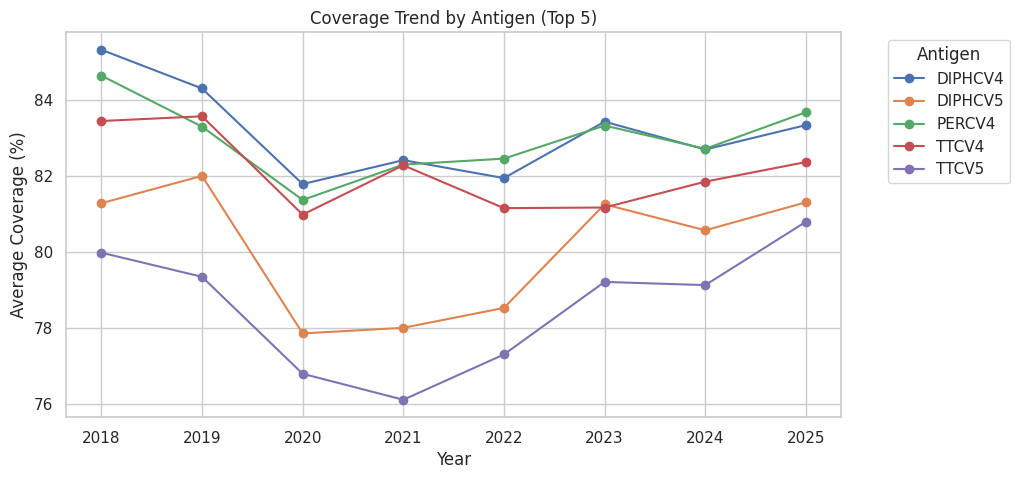

In [47]:
top_antigens = coverage_data["antigen"].value_counts().head(5).index
subset = coverage_data[coverage_data["antigen"].isin(top_antigens)]
trend = subset.groupby(["year", "antigen"])["coverage"].mean().unstack()
trend.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.title("Coverage Trend by Antigen (Top 5)")
plt.legend(title="Antigen", bbox_to_anchor=(1.05, 1))
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line chart lets us compare trends across multiple categories (antigens) and time simultaneously — a genuine multivariate view.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: do all antigens follow the same dip/recovery pattern, or do some diverge?)*


##### 3. Will the gained insights help creating a positive business impact?

Reveals whether some vaccines recovered faster than others post-disruption, informing which programs need extra support.


#### Chart - 18 — Disease Cases Trend by Region Over Time (Multivariate)

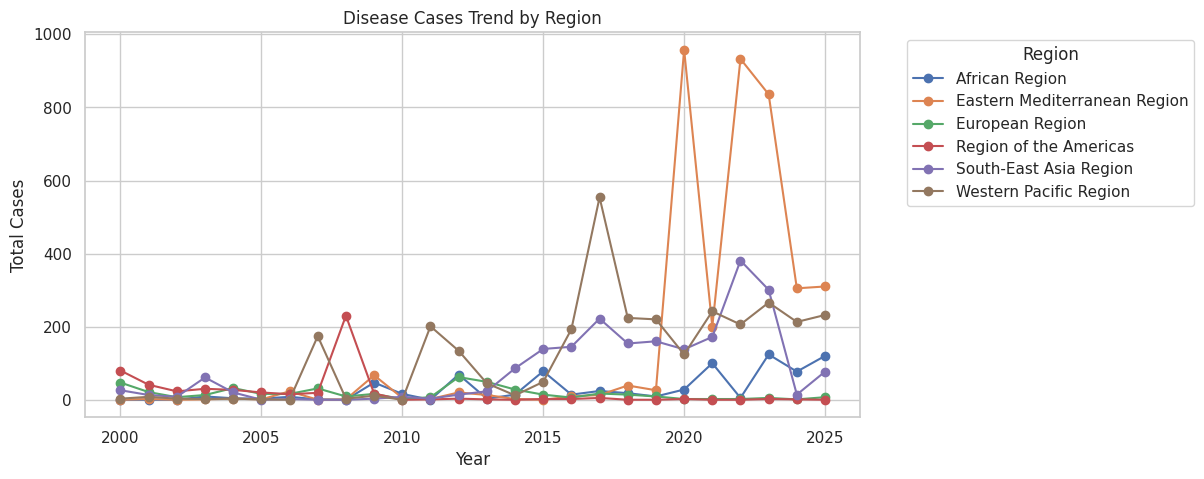

In [49]:
if not disease_cases.empty:
    region_trend = disease_cases.groupby(["year", "country / region"])["cases"].sum().unstack()
    region_trend.plot(marker="o")
    plt.xlabel("Year")
    plt.ylabel("Total Cases")
    plt.title("Disease Cases Trend by Region")
    plt.legend(title="Region", bbox_to_anchor=(1.05, 1))
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Disease Cases Trend by Region (No Data)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, "No disease cases data to display", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.show()

##### 1. Why did you pick the specific chart?

Multi-line chart to compare how disease burden evolved differently across regions over time.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: any region showing a sudden spike in a specific year, e.g. an outbreak?)*


##### 3. Will the gained insights help creating a positive business impact?

Pinpoints exactly when and where outbreaks occurred, which is directly actionable for outbreak-response planning.


#### Chart - 19 — Correlation Heatmap

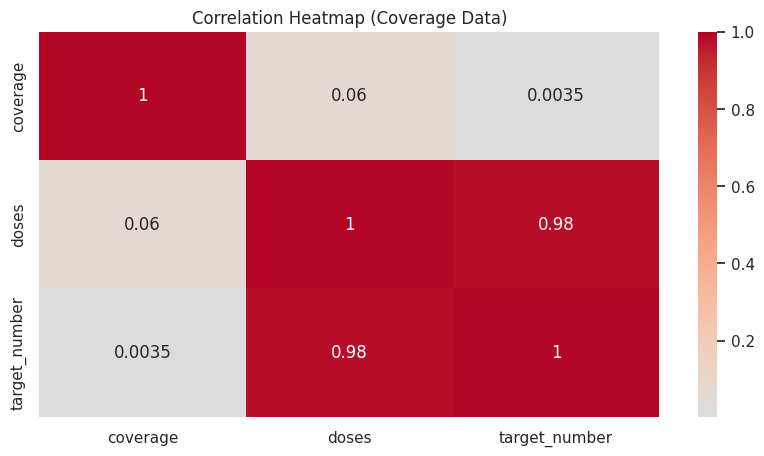

In [50]:
numeric_cols = coverage_data[["coverage", "doses", "target_number"]].dropna()
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Coverage Data)")
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to see linear relationships between all numeric variables at once.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: which pairs are strongly correlated, e.g. doses and target_number?)*


##### 3. Will the gained insights help creating a positive business impact?

Confirms which variables move together, guiding which features would matter most for any predictive/forecasting work later.


#### Chart - 20 — Pair Plot

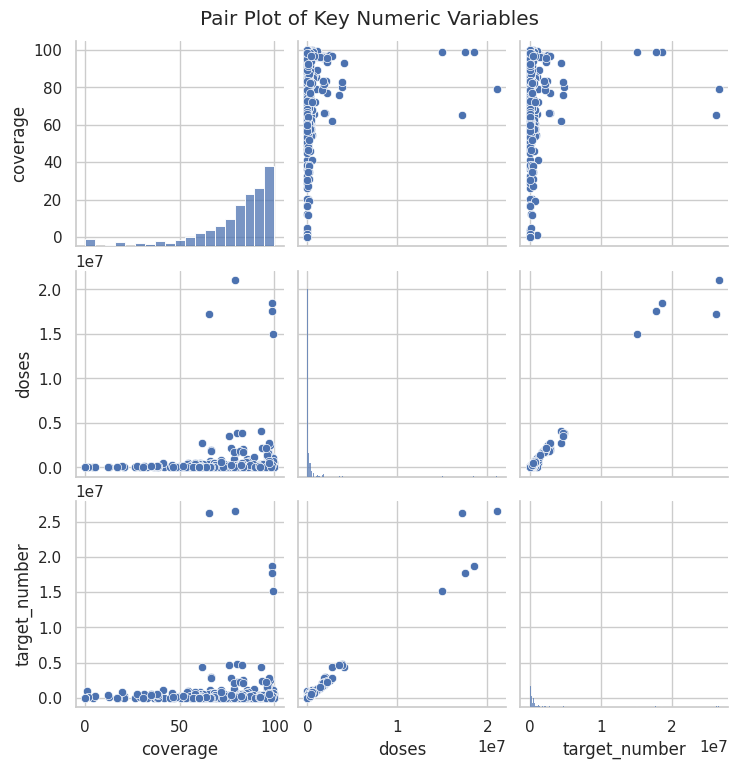

In [51]:
sample = coverage_data[["coverage", "doses", "target_number"]].dropna().sample(min(500, len(coverage_data)), random_state=42)
sns.pairplot(sample)
plt.suptitle("Pair Plot of Key Numeric Variables", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise scatter relationship plus individual distributions in one view — a fast way to spot patterns across several numeric variables at once.


##### 2. What is/are the insight(s) found from the chart?

*(Run and describe: any nonlinear patterns or clusters visible across the scatter panels?)*


##### 3. Will the gained insights help creating a positive business impact?

Gives a full multivariate snapshot in one chart, useful for spotting relationships that single scatter plots might miss.


## 5. Solution to Business Objective

#### What do you suggest the client to achieve Business Objective?

*(Answer after running all charts above — tie back to the brief's business use cases: public health strategy, disease prevention, resource allocation, global health policy. Reference specific findings, e.g. "Prioritize resource allocation to [region] which shows both the lowest coverage and highest case burden.")*


# Conclusion

*(Summarize: what the data showed overall about global vaccination coverage trends, which regions/countries need attention, and how coverage relates to disease incidence, referencing the specific charts above.)*
